In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)

/tmp/ipykernel_7216/1553962011.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train.csv')


Train shape: (100000, 28)
Test shape : (50000, 27)


In [ ]:
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
train.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [ ]:
print(train['Credit_Score'].value_counts())

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


---
## Objective 2: Preprocessing

In [ ]:
drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month']
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols,  inplace=True)
train.head(10)

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,28_,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,28,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,7,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


Columns with missing values:
Monthly_Inhand_Salary      15002
Type_of_Loan               11408
Num_of_Delayed_Payment      7002
Num_Credit_Inquiries        1965
Credit_History_Age          9030
Amount_invested_monthly     4479
Monthly_Balance             1200
dtype: int64


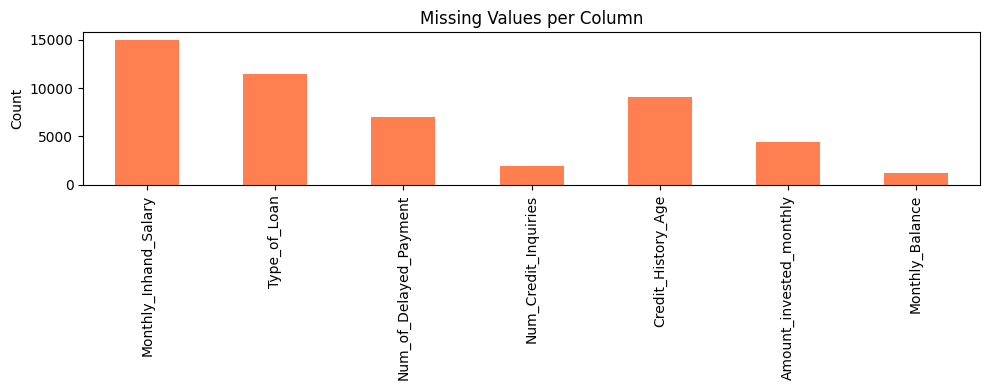

In [ ]:
missing = train.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)

plt.figure(figsize=(10,4))
missing.plot(kind='bar', color='coral')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
def parse_credit_age(val):
  try:
    parts = str(val).split()
    years  = int(parts[0]) if len(parts) > 0 else 0
    months = int(parts[3]) if len(parts) > 3 else 0
    return years * 12 + months
  except:
    return np.nan

for df in [train, test]:
    df['Credit_History_Age'] = df['Credit_History_Age'].apply(parse_credit_age)

print('Credit_History_Age converted to months')
print(train['Credit_History_Age'].head())

Credit_History_Age converted to months
0    265.0
1      NaN
2    267.0
3    268.0
4    269.0
Name: Credit_History_Age, dtype: float64


In [ ]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Credit_Score']

for col in cat_cols:
    mode_val = train[col].mode()[0]
    train[col].fillna(mode_val, inplace=True)
    test[col].fillna(mode_val,  inplace=True)

print('Total remaining nulls in train:', train.isnull().sum().sum())

/tmp/ipykernel_7216/1671403569.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_7216/1671403569.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

Total remaining nulls in train: 25997


In [ ]:
le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

# Encode target
label_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
train['Credit_Score'] = train['Credit_Score'].map(label_map)
print('Encoding done. Target mapping:', label_map)

Encoding done. Target mapping: {'Poor': 0, 'Standard': 1, 'Good': 2}


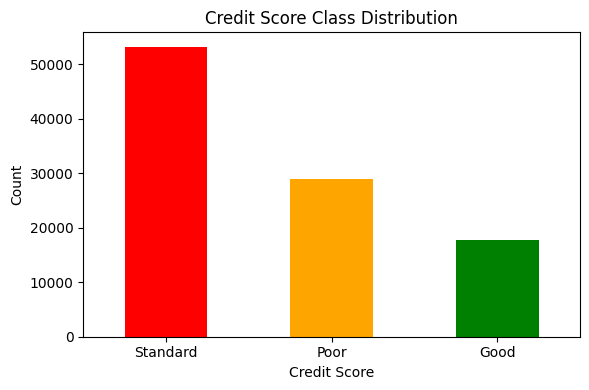

In [ ]:
plt.figure(figsize=(6,4))
train['Credit_Score'].map({0:'Poor',1:'Standard',2:'Good'}).value_counts().plot(
    kind='bar', color=['red','orange','green'])
plt.title('Credit Score Class Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

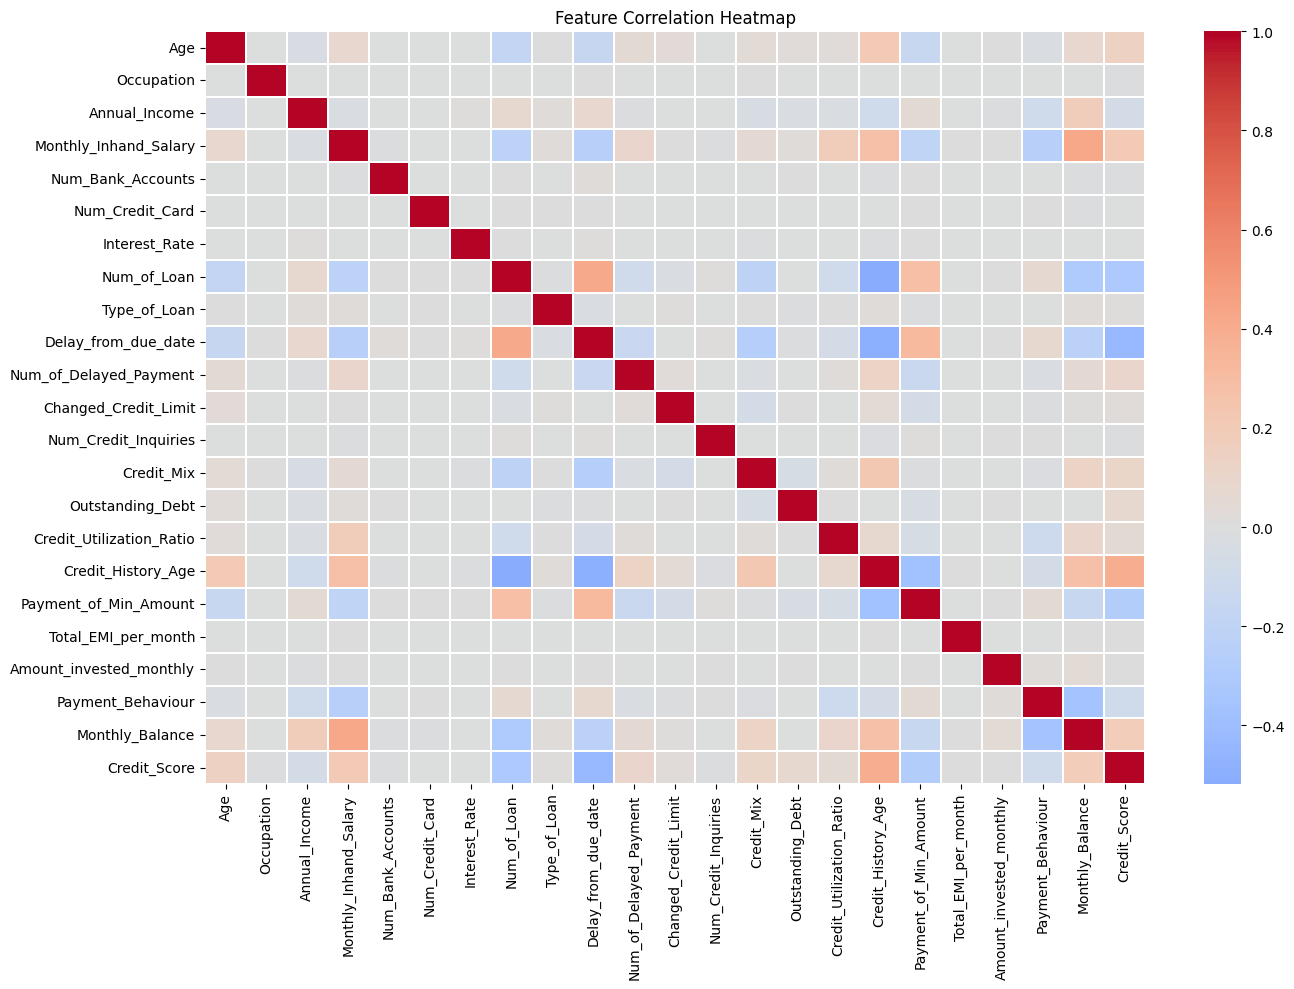

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(train.corr(), cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

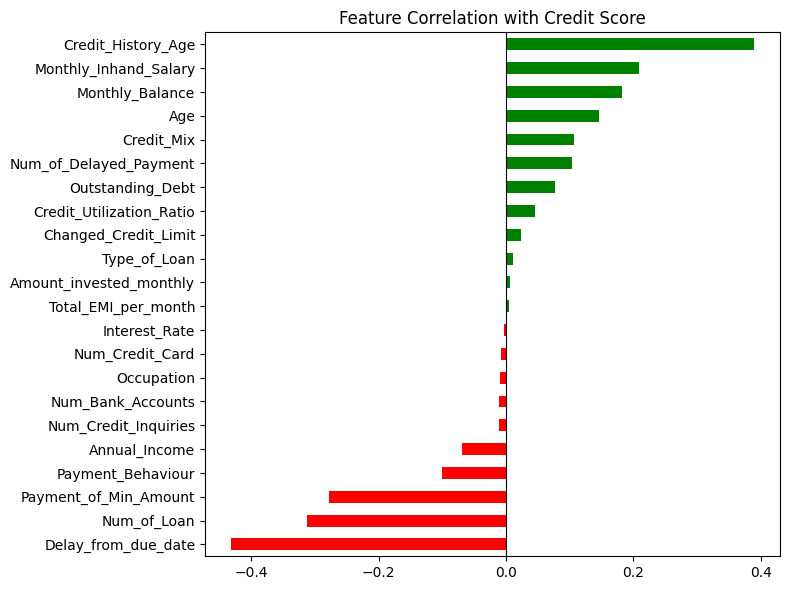

In [ ]:
corr_target = train.corr()['Credit_Score'].drop('Credit_Score').sort_values()
plt.figure(figsize=(8,6))
corr_target.plot(kind='barh', color=corr_target.map(lambda x: 'green' if x > 0 else 'red'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Credit Score')
plt.tight_layout()
plt.show()

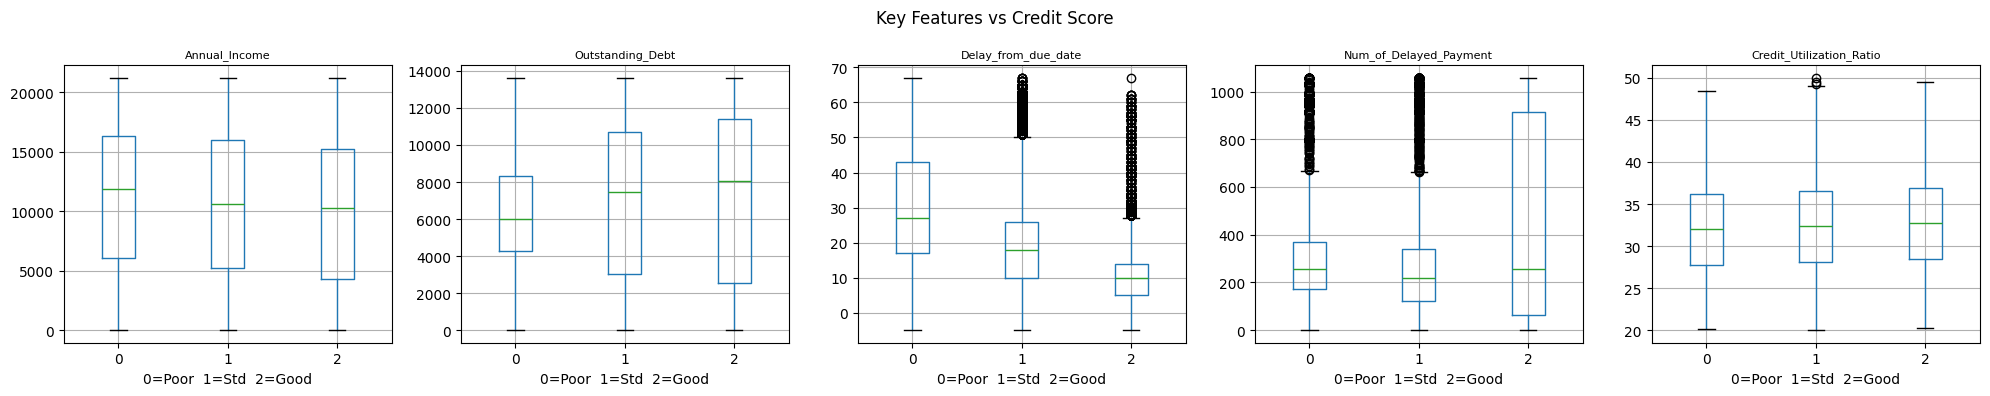

In [ ]:
key_features = ['Annual_Income', 'Outstanding_Debt', 'Delay_from_due_date',
                 'Num_of_Delayed_Payment', 'Credit_Utilization_Ratio']

fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, feat in zip(axes, key_features):
    train.boxplot(column=feat, by='Credit_Score', ax=ax)
    ax.set_title(feat, fontsize=8)
    ax.set_xlabel('0=Poor  1=Std  2=Good')
plt.suptitle('Key Features vs Credit Score')
plt.tight_layout()
plt.show()

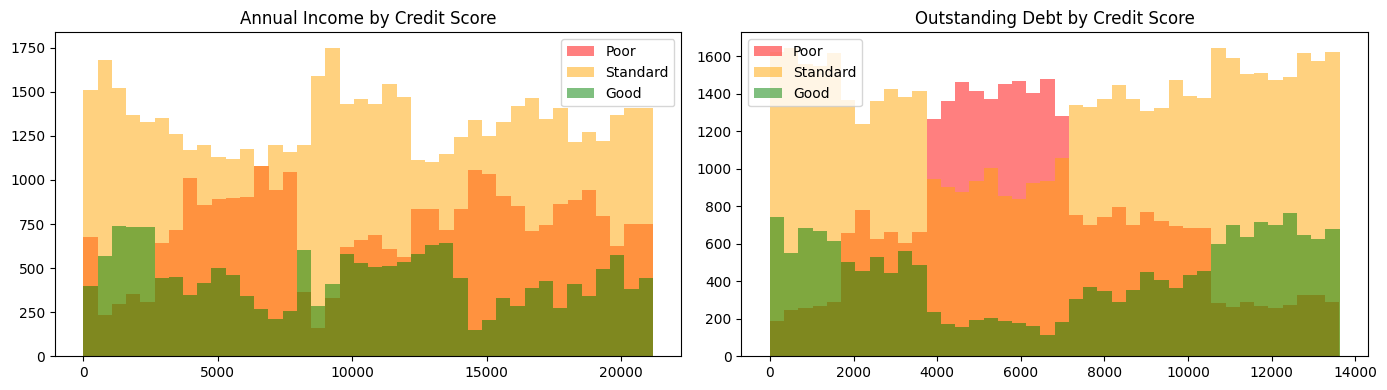

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
for label, name, color in zip([0,1,2], ['Poor','Standard','Good'], ['red','orange','green']):
    mask = train['Credit_Score'] == label
    axes[0].hist(train.loc[mask, 'Annual_Income'],    bins=40, alpha=0.5, label=name, color=color)
    axes[1].hist(train.loc[mask, 'Outstanding_Debt'], bins=40, alpha=0.5, label=name, color=color)

axes[0].set_title('Annual Income by Credit Score')
axes[1].set_title('Outstanding Debt by Credit Score')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

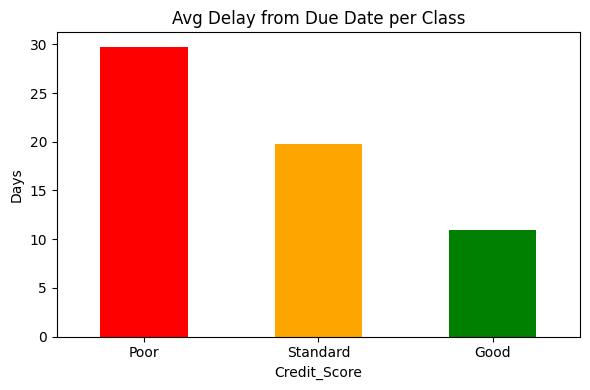

In [ ]:
# Avg delay from due date per credit score class
plt.figure(figsize=(6,4))
train.groupby('Credit_Score')['Delay_from_due_date'].mean().plot(
    kind='bar', color=['red','orange','green'])
plt.xticks([0,1,2], ['Poor','Standard','Good'], rotation=0)
plt.title('Avg Delay from Due Date per Class')
plt.ylabel('Days')
plt.tight_layout()
plt.show()

Components needed to explain 95% variance: 20


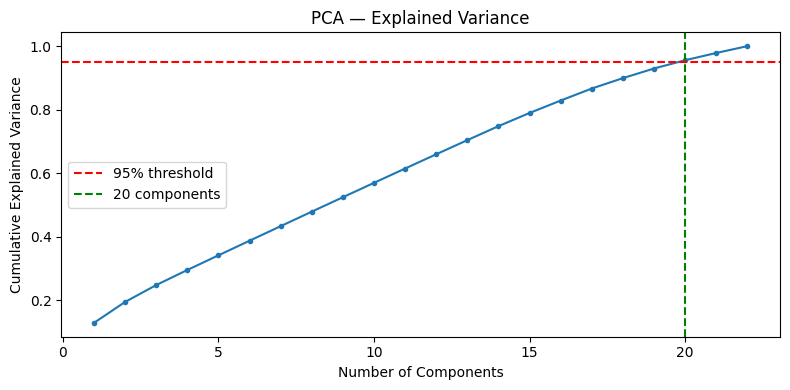

In [ ]:
X = train.drop('Credit_Score', axis=1)
y = train['Credit_Score']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full  = PCA()
pca_full.fit(X_scaled)

explained = np.cumsum(pca_full.explained_variance_ratio_)
n_95      = np.argmax(explained >= 0.95) + 1
print(f'Components needed to explain 95% variance: {n_95}')

plt.figure(figsize=(8,4))
plt.plot(range(1, len(explained)+1), explained, marker='.')
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(n_95, color='g', linestyle='--', label=f'{n_95} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

Top 10 features by PCA magnitude:
                          PC1     PC2  magnitude
Monthly_Balance        0.3422 -0.4550     0.5694
Payment_Behaviour     -0.1779  0.5395     0.5680
Credit_History_Age     0.4384  0.2030     0.4831
Delay_from_due_date   -0.4142 -0.2036     0.4615
Monthly_Inhand_Salary  0.3142 -0.3206     0.4489
Num_of_Loan           -0.4162 -0.1627     0.4469
Annual_Income         -0.0414 -0.4155     0.4176
Payment_of_Min_Amount -0.3182 -0.1697     0.3606
Age                    0.1921  0.1506     0.2441
Credit_Mix             0.1955  0.1446     0.2432


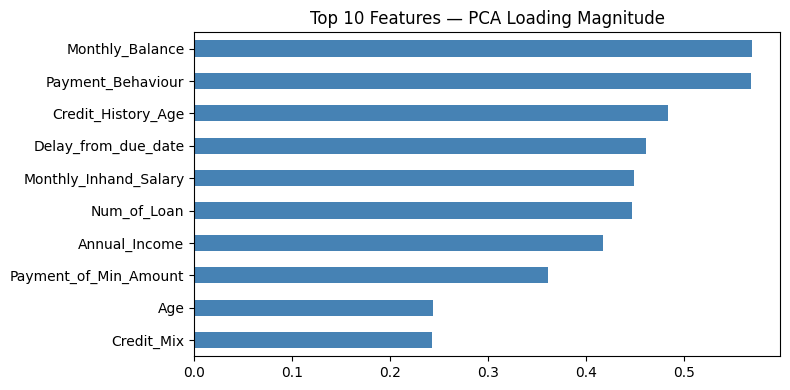

In [ ]:
# Top features by PCA loading magnitude
pca_2  = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

loadings = pd.DataFrame(pca_2.components_.T, index=X.columns, columns=['PC1','PC2'])
loadings['magnitude'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
top10 = loadings.nlargest(10, 'magnitude')

print('Top 10 features by PCA magnitude:')
print(top10[['PC1','PC2','magnitude']].round(4))

plt.figure(figsize=(8,4))
top10['magnitude'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Features — PCA Loading Magnitude')
plt.tight_layout()
plt.show()

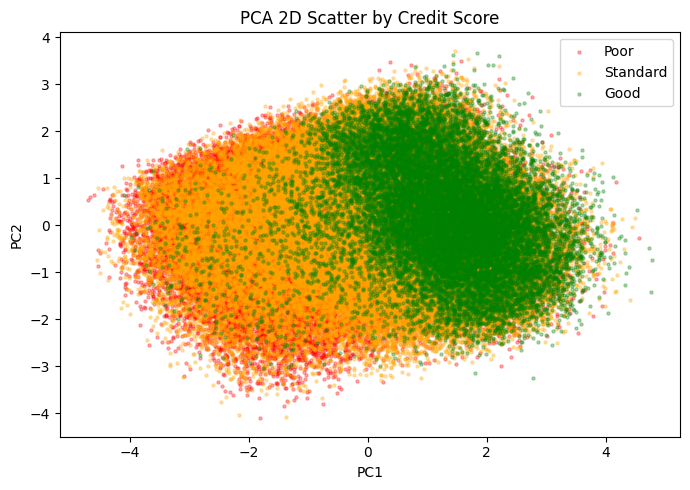

In [ ]:
# PCA 2D scatter
plt.figure(figsize=(7,5))
colors = {0:'red', 1:'orange', 2:'green'}
for label, name in zip([0,1,2], ['Poor','Standard','Good']):
    mask = y == label
    plt.scatter(X_pca2[mask,0], X_pca2[mask,1],
                c=colors[label], label=name, alpha=0.3, s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter by Credit Score')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Reduce to 95% variance components
pca_n     = PCA(n_components=n_95)
X_reduced = pca_n.fit_transform(X_scaled)

X_train, X_val, y_train, y_val = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape}')
print(f'Val   size: {X_val.shape}')

Train size: (80000, 20)
Val   size: (20000, 20)


In [ ]:
classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'SVM (RBF)'           : SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}

for name, clf in classifiers.items():
    print(f'Training: {name} ...', end=' ')
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_val)
    y_proba = clf.predict_proba(X_val)

    acc    = accuracy_score(y_val, y_pred)
    roc    = roc_auc_score(y_val, y_proba, multi_class='ovr', average='macro')
    report = classification_report(y_val, y_pred,
                                   target_names=['Poor','Standard','Good'],
                                   output_dict=True)
    results[name] = {
        'accuracy' : acc,
        'roc_auc'  : roc,
        'precision': report['macro avg']['precision'],
        'recall'   : report['macro avg']['recall'],
        'f1'       : report['macro avg']['f1-score'],
        'y_pred'   : y_pred
    }
    print(f'Accuracy={acc:.4f}   ROC-AUC={roc:.4f}')

Training: Logistic Regression ... Accuracy=0.5895   ROC-AUC=0.7546
Training: Decision Tree ... Accuracy=0.6065   ROC-AUC=0.7586
Training: Random Forest ... Accuracy=0.6493   ROC-AUC=0.8098
Training: K-Nearest Neighbors ... Accuracy=0.6161   ROC-AUC=0.7701
Training: SVM (RBF) ... Accuracy=0.6410   ROC-AUC=0.7984


In [ ]:
# Comparison table
summary = pd.DataFrame({
    name: {
        'Accuracy' : r['accuracy'],
        'Precision': r['precision'],
        'Recall'   : r['recall'],
        'F1-Score' : r['f1'],
        'ROC-AUC'  : r['roc_auc']
    }
    for name, r in results.items()
}).T.round(4)

print('=== Model Comparison ===')
print(summary.to_string())

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.5895     0.5719  0.4989    0.5160   0.7546
Decision Tree          0.6064     0.5799  0.5648    0.5698   0.7586
Random Forest          0.6493     0.6331  0.5860    0.6026   0.8098
K-Nearest Neighbors    0.6162     0.5865  0.5542    0.5660   0.7701
SVM (RBF)              0.6410     0.6191  0.6117    0.6105   0.7984


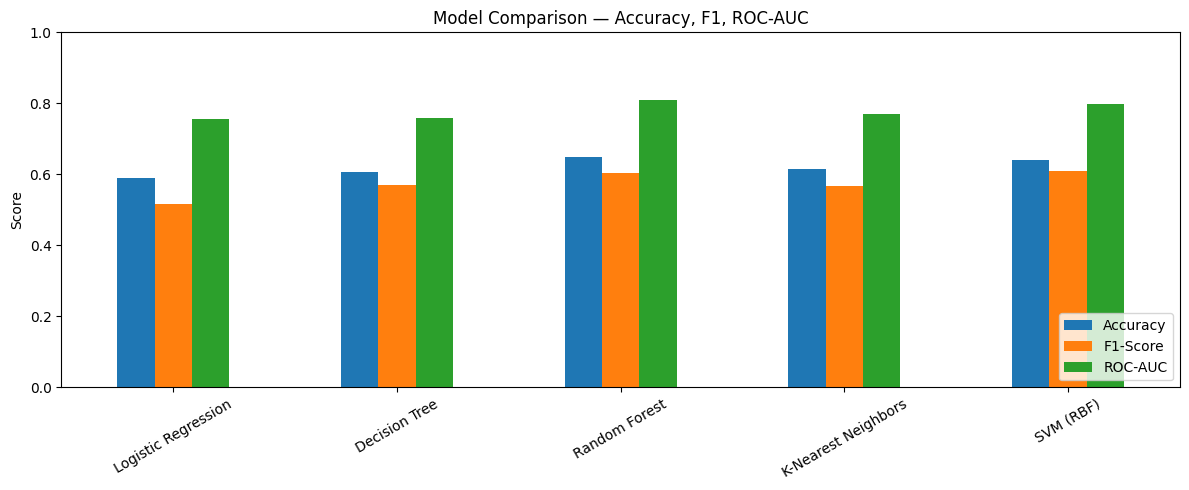

In [ ]:
# Bar chart comparison
summary[['Accuracy','F1-Score','ROC-AUC']].plot(kind='bar', figsize=(12,5), rot=30)
plt.title('Model Comparison — Accuracy, F1, ROC-AUC')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

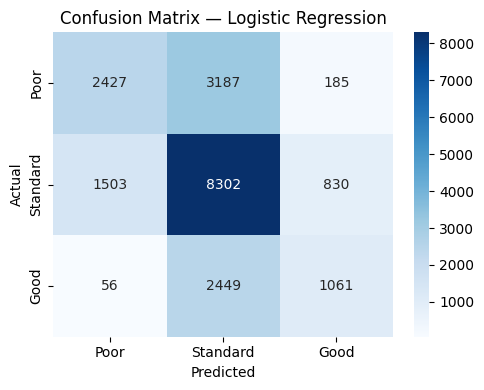

  Accuracy : 0.5895
  ROC-AUC  : 0.7546



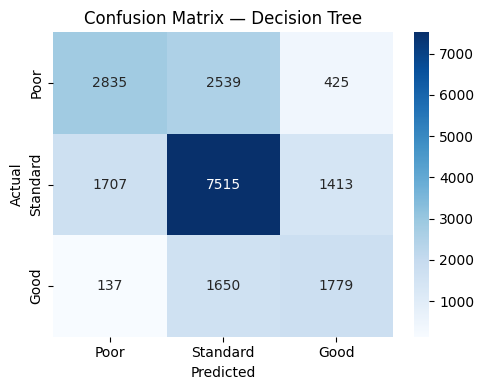

  Accuracy : 0.6065
  ROC-AUC  : 0.7586



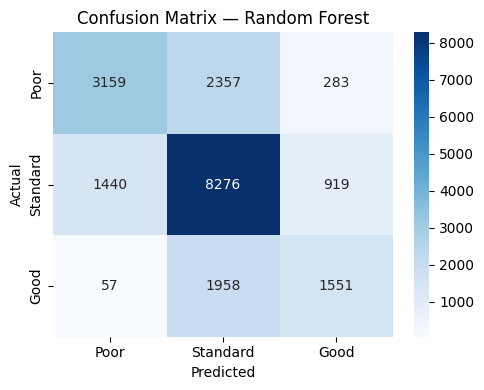

  Accuracy : 0.6493
  ROC-AUC  : 0.8098



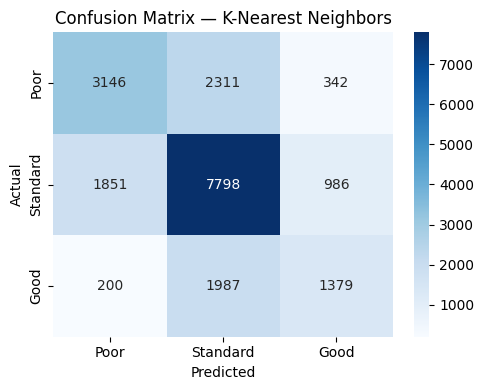

  Accuracy : 0.6161
  ROC-AUC  : 0.7701



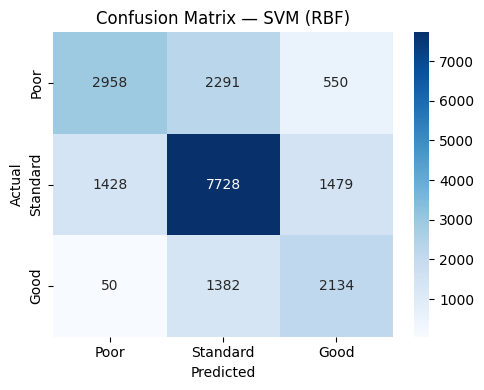

  Accuracy : 0.6410
  ROC-AUC  : 0.7984



In [ ]:
# Individual Confusion Matrix for each classifier
class_names = ['Poor', 'Standard', 'Good']

for name, r in results.items():
    cm = confusion_matrix(y_val, r['y_pred'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    print(f'  Accuracy : {r["accuracy"]:.4f}')
    print(f'  ROC-AUC  : {r["roc_auc"]:.4f}')
    print()

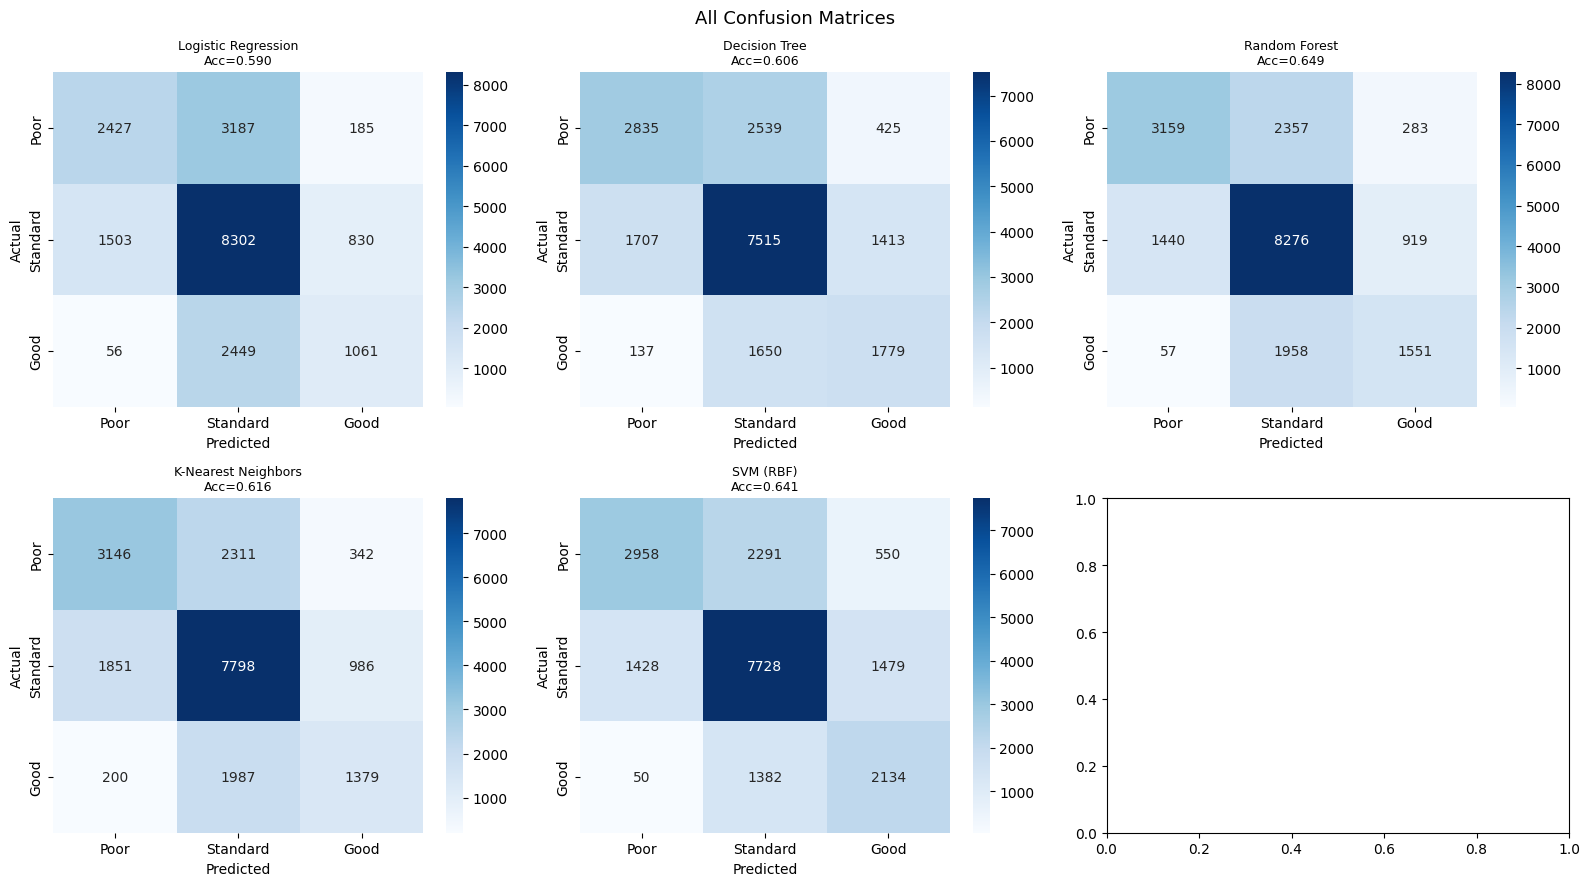

In [ ]:
# All confusion matrices in one grid
fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names,
                yticklabels=class_names)
    ax.set_title(f'{name}\nAcc={r["accuracy"]:.3f}', fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('All Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Classification report of best model
best_name = summary['Accuracy'].idxmax()
print(f'Best Model: {best_name}')
print()
print(classification_report(y_val, results[best_name]['y_pred'],
                             target_names=['Poor','Standard','Good']))

Best Model: Random Forest

              precision    recall  f1-score   support

        Poor       0.68      0.54      0.60      5799
    Standard       0.66      0.78      0.71     10635
        Good       0.56      0.43      0.49      3566

    accuracy                           0.65     20000
   macro avg       0.63      0.59      0.60     20000
weighted avg       0.65      0.65      0.64     20000

